In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np

client = bigquery.Client(project='project3grupo1')

query = """
SELECT *
FROM `project3grupo1.dbt_transform.mart_occupancy_features`
WHERE date != '2026-05-16'
QUALIFY ROW_NUMBER() OVER (PARTITION BY listing_id, date ORDER BY listing_id) = 1
"""

df_raw = client.query(query).to_dataframe()
print(f'Shape: {df_raw.shape}')
print(f'Rango de fechas: {df_raw["date"].min()} → {df_raw["date"].max()}')

/Users/marta/Documents/Máster/IADATA-PROJECT3/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Shape: (3327493, 34)
Rango de fechas: 2025-06-23 → 2026-05-15


In [3]:
df_raw = df_raw[df_raw['temp_mean'].notna()].copy()
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw.to_parquet('mart_occupancy_features.parquet', index=False)
print(f'Shape: {df_raw.shape}')
print(f'Rango de fechas: {df_raw["date"].min()} → {df_raw["date"].max()}')

Shape: (3327493, 34)
Rango de fechas: 2025-06-23 00:00:00 → 2026-05-15 00:00:00


In [4]:
precio_por_listing = df_raw.groupby('listing_id')['listing_price'].agg(['min', 'max', 'std', 'nunique'])
precio_por_listing.columns = ['precio_min', 'precio_max', 'precio_std', 'n_precios_distintos']

print(f'Listings con precio fijo (1 único precio): {(precio_por_listing["n_precios_distintos"] == 1).sum():,}')
print(f'Listings con precio variable             : {(precio_por_listing["n_precios_distintos"] > 1).sum():,}')
print(f'\nDistribución de n_precios_distintos:')
print(precio_por_listing['n_precios_distintos'].describe())

Listings con precio fijo (1 único precio): 12,273
Listings con precio variable             : 0

Distribución de n_precios_distintos:
count    12273.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: n_precios_distintos, dtype: float64


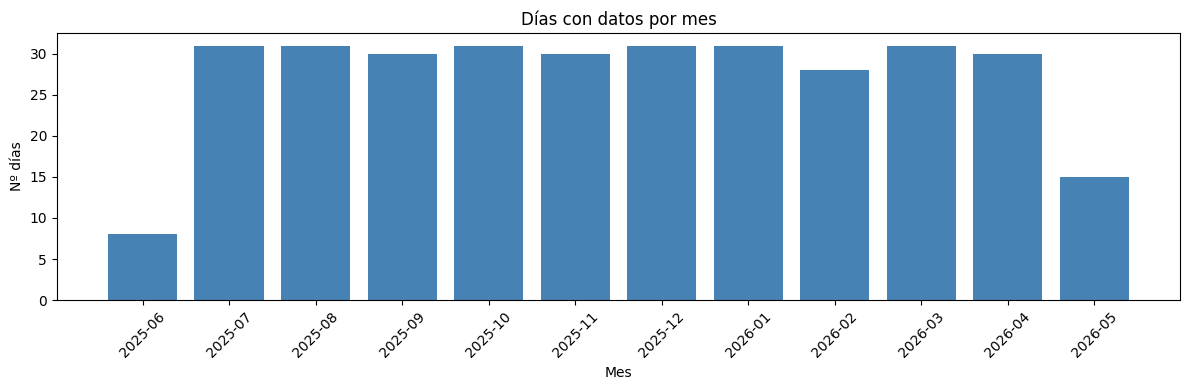

    mes  n_dias
2025-06       8
2025-07      31
2025-08      31
2025-09      30
2025-10      31
2025-11      30
2025-12      31
2026-01      31
2026-02      28
2026-03      31
2026-04      30
2026-05      15


In [5]:
import matplotlib.pyplot as plt

df_raw['year_month'] = df_raw['date'].dt.to_period('M')

dias_por_mes = df_raw.groupby('year_month')['date'].nunique().reset_index()
dias_por_mes.columns = ['mes', 'n_dias']

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(dias_por_mes['mes'].astype(str), dias_por_mes['n_dias'], color='steelblue')
ax.set_title('Días con datos por mes')
ax.set_xlabel('Mes')
ax.set_ylabel('Nº días')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(dias_por_mes.to_string(index=False))

In [6]:
train_end = '2026-02-28'
test_start = '2026-03-01'

df_train = df_raw[df_raw['date'] <= train_end].copy()
df_test  = df_raw[df_raw['date'] >= test_start].copy()

print(f'Train: {df_train.shape[0]:,} filas  ({df_train["date"].min().date()} → {df_train["date"].max().date()})')
print(f'Test : {df_test.shape[0]:,} filas  ({df_test["date"].min().date()} → {df_test["date"].max().date()})')
print(f'\nDistribución target train: {df_train["is_occupied"].mean():.3f}')
print(f'Distribución target test : {df_test["is_occupied"].mean():.3f}')

Train: 2,394,745 filas  (2025-06-23 → 2026-02-28)
Test : 932,748 filas  (2026-03-01 → 2026-05-15)

Distribución target train: 0.394
Distribución target test : 0.322


In [7]:
df_train['has_reviews'] = df_train['review_scores_rating'].notna().astype(int)
df_test['has_reviews']  = df_test['review_scores_rating'].notna().astype(int)

df_train['review_scores_rating'] = df_train['review_scores_rating'].fillna(0)
df_test['review_scores_rating']  = df_test['review_scores_rating'].fillna(0)

print(f'has_reviews en train: {df_train["has_reviews"].value_counts().to_dict()}')
print(f'has_reviews en test : {df_test["has_reviews"].value_counts().to_dict()}')

has_reviews en train: {1: 1940758, 0: 453987}
has_reviews en test : {1: 755516, 0: 177232}


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

FEATURES = [
    'month', 'day_of_week', 'is_weekend', 'days_to_next_holiday', 'is_holiday',
    'neighbourhood_cleansed', 'room_type', 'accommodates', 'listing_price',
    'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'has_reviews',
    'instant_bookable', 'temp_mean', 'precipitation_mm',
    'num_sports', 'num_festivals', 'total_attendance',
]

TARGET = 'is_occupied'

num_cols = ['month', 'day_of_week', 'is_weekend', 'days_to_next_holiday', 'is_holiday',
            'accommodates', 'listing_price', 'minimum_nights', 'number_of_reviews',
            'review_scores_rating', 'has_reviews', 'instant_bookable',
            'temp_mean', 'precipitation_mm', 'num_sports', 'num_festivals', 'total_attendance']

cat_cols = ['neighbourhood_cleansed', 'room_type']

numeric_pipeline = Pipeline([
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols),
])

X_train = df_train[FEATURES]
y_train = df_train[TARGET].astype(int)
X_test  = df_test[FEATURES]
y_test  = df_test[TARGET].astype(int)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f'Train: {X_train_processed.shape}')
print(f'Test : {X_test_processed.shape}')

Train: (2394745, 88)
Test : (932748, 88)


In [9]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, roc_auc_score, precision_score, recall_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

cv = TimeSeriesSplit(n_splits=5)

scorers = {
    'accuracy':  'accuracy',
    'f1':        make_scorer(f1_score, average='binary', zero_division=0),
    'precision': make_scorer(precision_score, average='binary', zero_division=0),
    'recall':    make_scorer(recall_score, average='binary', zero_division=0),
    'roc_auc':   'roc_auc',
}

ratio = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    'XGBoost':      XGBClassifier(n_estimators=300, max_depth=15, learning_rate=0.05,
                                   subsample=0.8, colsample_bytree=0.8,
                                   scale_pos_weight=ratio, eval_metric='logloss',
                                   random_state=42, n_jobs=-1),
}

results = []
for name, model in models.items():
    print(f'Entrenando {name}...')
    cv_res = cross_validate(model, X_train_processed, y_train, cv=cv, scoring=scorers, return_train_score=True)
    results.append({
        'model':     name,
        'f1_test':   cv_res['test_f1'].mean(),
        'f1_train':  cv_res['train_f1'].mean(),
        'f1_std':    cv_res['test_f1'].std(),
        'auc':       cv_res['test_roc_auc'].mean(),
        'precision': cv_res['test_precision'].mean(),
        'recall':    cv_res['test_recall'].mean(),
        'fit_time':  cv_res['fit_time'].mean(),
    })
    print(f'  F1={cv_res["test_f1"].mean():.4f}  AUC={cv_res["test_roc_auc"].mean():.4f}')

df_res = pd.DataFrame(results).sort_values('f1_test', ascending=False).reset_index(drop=True)
print(df_res.to_string(float_format='{:.4f}'.format))

Entrenando RandomForest...
  F1=0.7886  AUC=0.9152
Entrenando XGBoost...
  F1=0.8242  AUC=0.9313
          model  f1_test  f1_train  f1_std    auc  precision  recall  fit_time
0       XGBoost   0.8242    0.8761  0.0109 0.9313     0.7900  0.8616   16.3223
1  RandomForest   0.7886    0.9954  0.0272 0.9152     0.8202  0.7595   31.3046


              precision    recall  f1-score   support

       libre       0.86      0.88      0.87    632675
     ocupado       0.74      0.70      0.72    300073

    accuracy                           0.82    932748
   macro avg       0.80      0.79      0.80    932748
weighted avg       0.82      0.82      0.82    932748



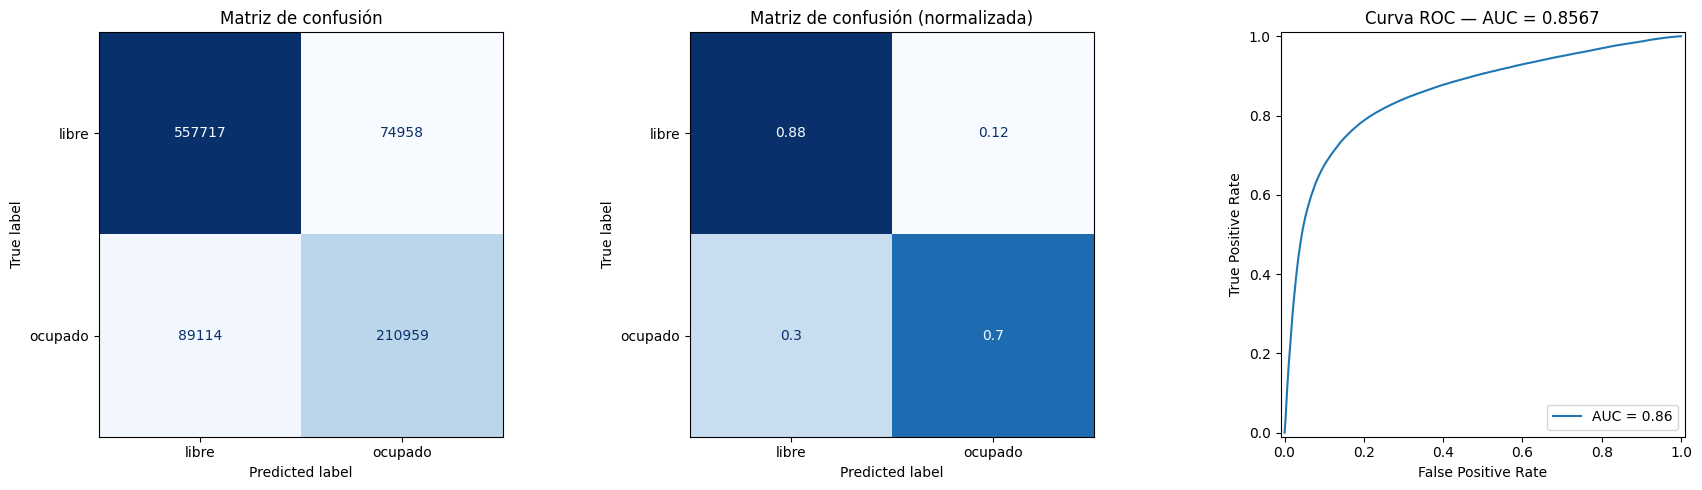

In [10]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay

best_model = XGBClassifier(
    n_estimators=300,
    max_depth=15,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train_processed, y_train)
y_pred  = best_model.predict(X_test_processed)
y_proba = best_model.predict_proba(X_test_processed)[:, 1]

print(classification_report(y_test, y_pred, target_names=['libre', 'ocupado'], zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[0], cmap='Blues',
    colorbar=False, display_labels=['libre', 'ocupado']
)
axes[0].set_title('Matriz de confusión')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[1], cmap='Blues',
    colorbar=False, normalize='true', display_labels=['libre', 'ocupado']
)
axes[1].set_title('Matriz de confusión (normalizada)')

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot(ax=axes[2])
axes[2].set_title(f'Curva ROC — AUC = {roc_auc:.4f}')

plt.tight_layout()
plt.show()

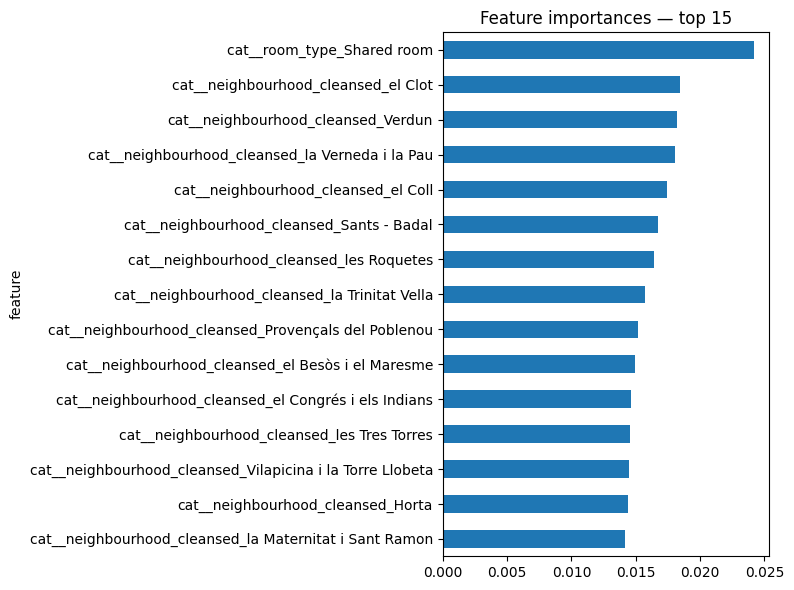

In [11]:
feature_names = preprocessor.get_feature_names_out()

fi_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': best_model.feature_importances_,
}).sort_values('importance', ascending=False)

fi_df.head(15).plot(
    kind='barh', x='feature', y='importance',
    figsize=(8, 6), title='Feature importances — top 15', legend=False
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

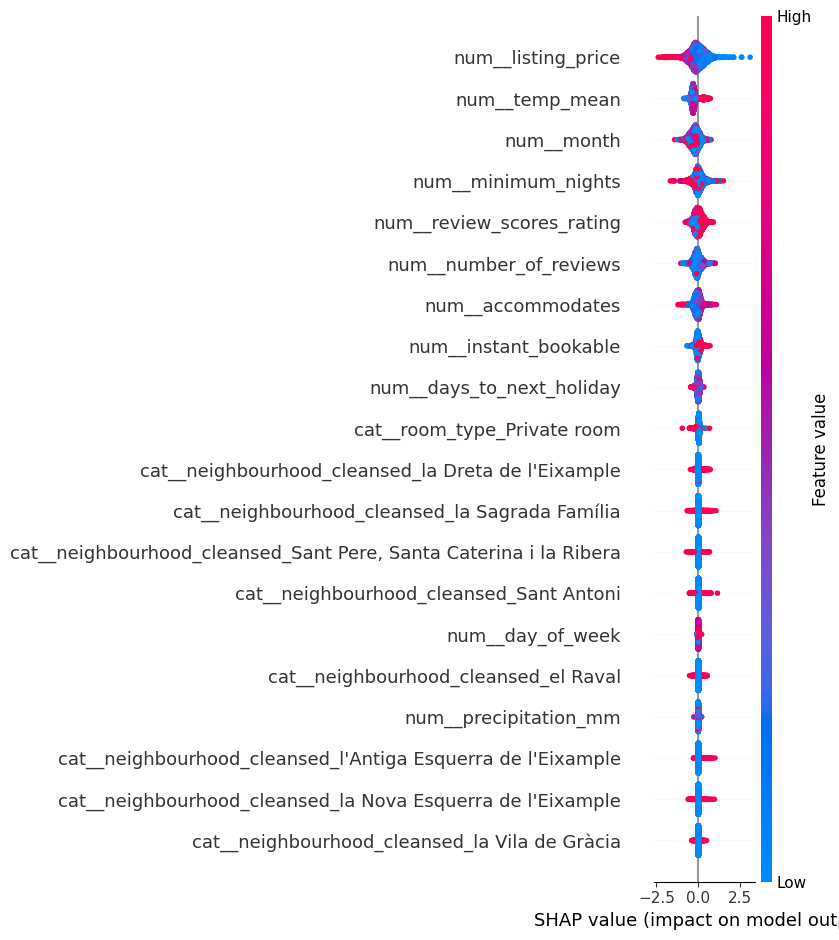

In [12]:
import shap

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_processed[:5000])

shap.summary_plot(shap_values, X_test_processed[:5000], feature_names=feature_names)

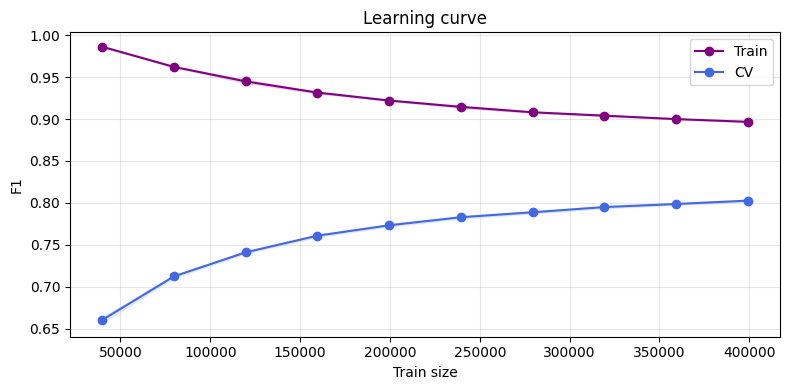

Gap final (F1): 0.0939


In [13]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_processed, y_train,
    cv=cv, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1, shuffle=True, random_state=42
)

tm, ts = train_scores.mean(axis=1), train_scores.std(axis=1)
vm, vs = val_scores.mean(axis=1),   val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_sizes, tm, 'o-', color='purple',    label='Train')
ax.plot(train_sizes, vm, 'o-', color='royalblue', label='CV')
ax.fill_between(train_sizes, tm-ts, tm+ts, alpha=0.1, color='purple')
ax.fill_between(train_sizes, vm-vs, vm+vs, alpha=0.1, color='royalblue')
ax.set(xlabel='Train size', ylabel='F1', title='Learning curve')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Gap final (F1): {tm[-1] - vm[-1]:.4f}')

## Conclusiones — Experimento 04

 ## Novedades respecto al exp_03
 - Split temporal en lugar de aleatorio (más realista)
 - has_reviews como flag de listings sin reseñas (~19%)
 - listing_price confirmado como estático → sin fuga de datos
 - Desbalanceo temporal: train 39.4% ocupado vs test 32.2% ocupado
   (marzo-mayo tiene menos ocupación real que el periodo de train)

 ### Comparativa XGBoost exp_03 vs exp_04
 | Métrica        | exp_03 (aleatorio) | exp_04 (temporal) |
 |---|---|---|
 | F1 ocupado     | 0.835              | 0.720             |
 | F1 libre       | 0.890              | 0.870             |
 | AUC            | 0.944              | 0.857             |
 | Recall ocupado | 0.870              | 0.700             |
 | Gap LC (F1)    | 0.030              | 0.094             |
#
 La caída es esperada — el split temporal es más honesto y más exigente.
 El mayor gap en la learning curve indica más overfitting temporal:
 el modelo aprende patrones del pasado que no generalizan igual al futuro.

 ## Limitaciones
 - El desbalanceo temporal (menos ocupación en test) penaliza las métricas
   más allá de la capacidad real del modelo
 - Sin feature engineering prospectivo: el modelo no tiene información
   de la tendencia histórica de cada listing

 ## Próximo experimento
 - Feature engineering: tasa histórica de ocupación por listing
   (calculada con datos anteriores a cada fecha, sin leakage)
 - Tasa de ocupación por barrio+mes
 - Evaluar impacto de has_reviews con SHAP